In [1]:
import torch 
import torch.nn as nn 
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [17]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_set = CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=False
)
test_set = CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=False
)

In [3]:
train_set

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [4]:
test_set

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [5]:
trainloader = DataLoader(train_set, batch_size=64, shuffle=True)
testloader = DataLoader(test_set, batch_size=64,)

In [6]:
# building cnn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4 * 4 * 128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)

        return x

In [7]:
model = CNN()

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [15]:
#training my CNN

epochs = 10

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for i, (images, labels) in enumerate(trainloader):
        
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")


epoch=1/10 & loss=0.5459231834696687
epoch=2/10 & loss=0.44997137213302085
epoch=3/10 & loss=0.3665797659541335
epoch=4/10 & loss=0.29248415624432245
epoch=5/10 & loss=0.22586720020931852
epoch=6/10 & loss=0.17786529166219028
epoch=7/10 & loss=0.1457645339996118
epoch=8/10 & loss=0.12067191215360637
epoch=9/10 & loss=0.10338871272952507
epoch=10/10 & loss=0.09446093038824932


In [18]:
correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)
        _, predicted =torch.max(outputs,1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels/total_labels*100}%")

accuracy = 96.044%


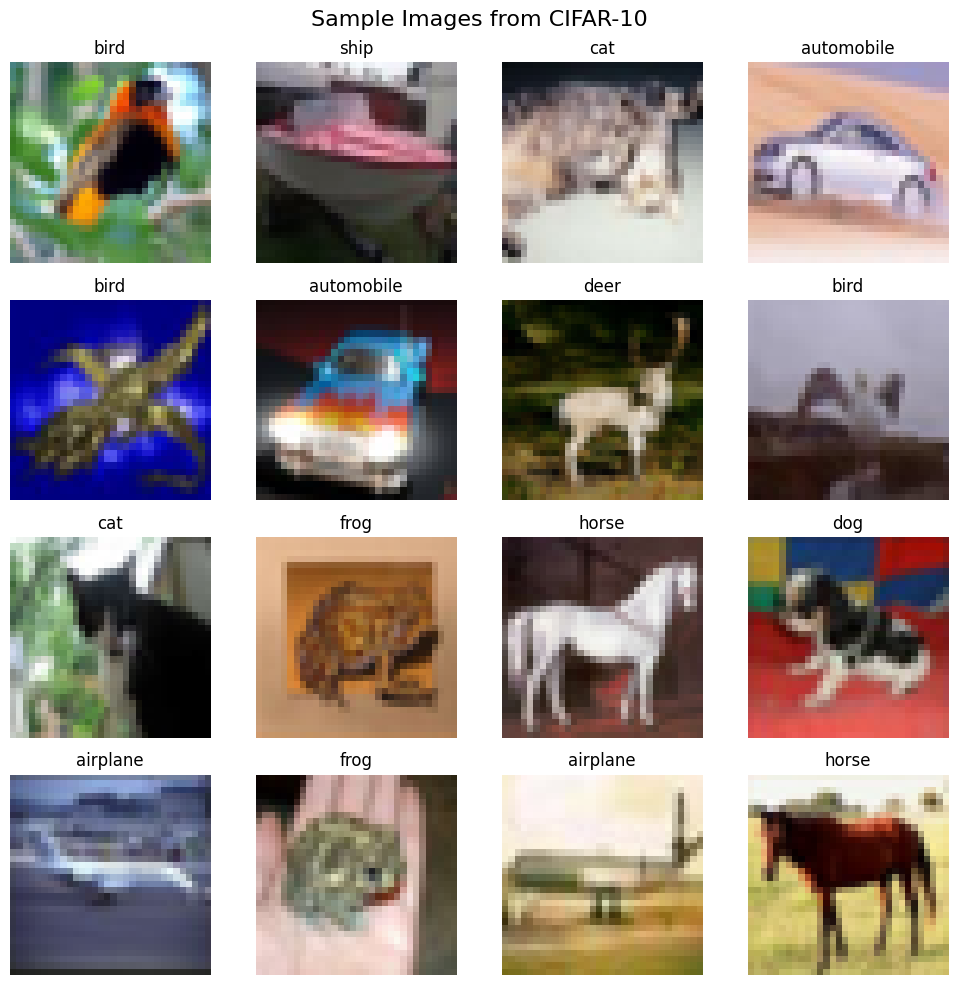

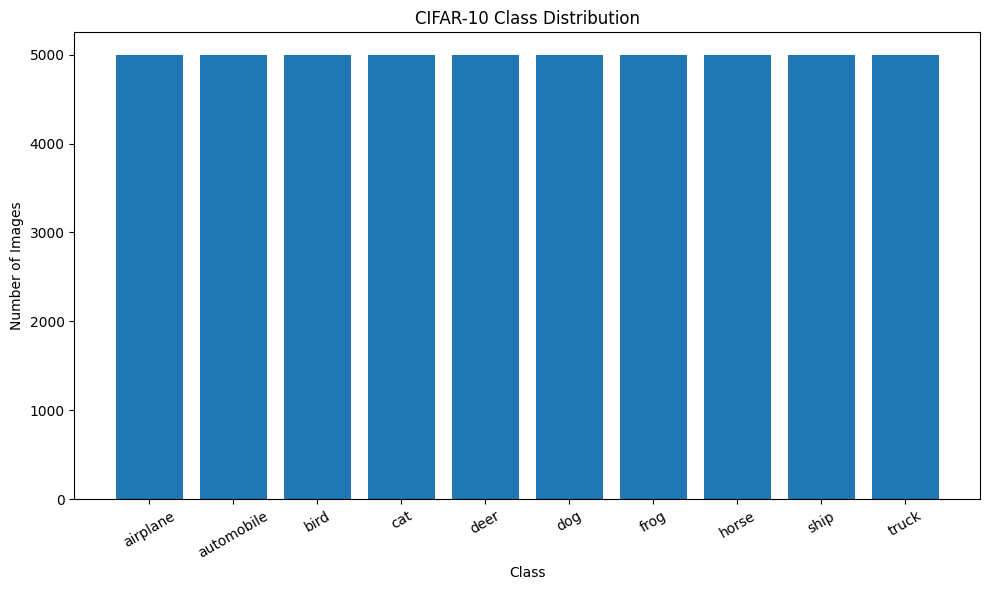

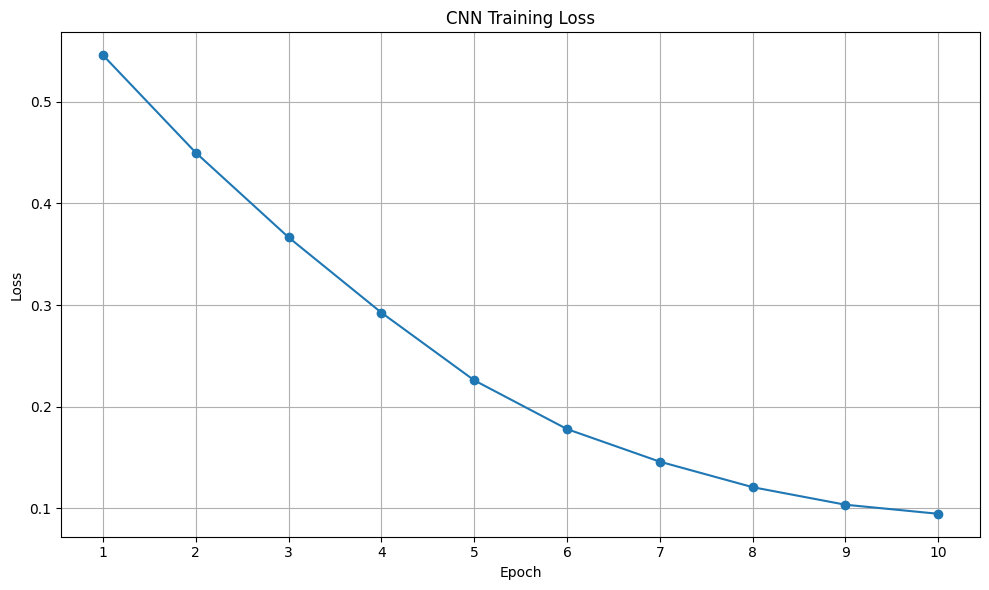

<Figure size 1000x1000 with 0 Axes>

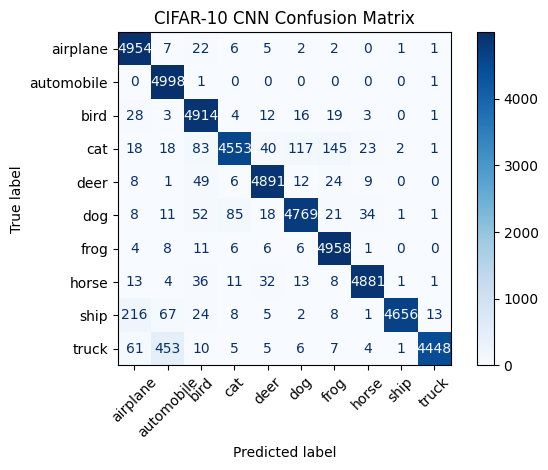

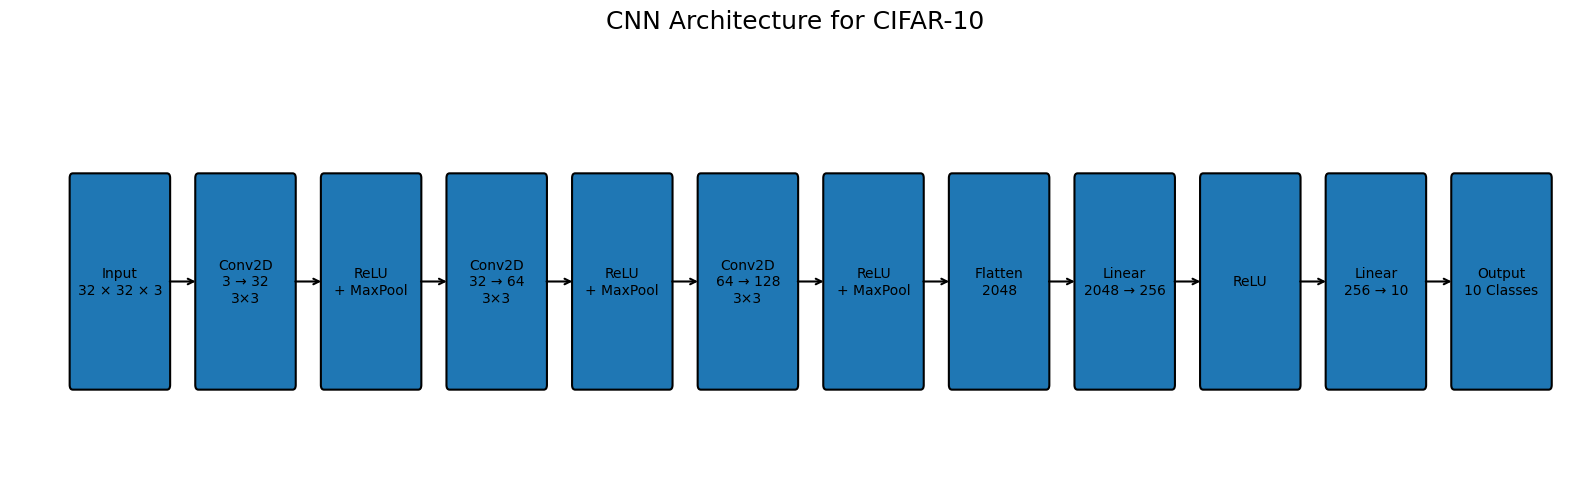

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# CIFAR-10 class names
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


# ============================================================
# 1. SAMPLE IMAGES FROM CIFAR-10
# ============================================================

images, labels = next(iter(trainloader))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    # Convert from [-1, 1] back to [0, 1]
    image = images[i] / 2 + 0.5

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(classes[labels[i].item()])
    ax.axis("off")

plt.suptitle("Sample Images from CIFAR-10", fontsize=16)
plt.tight_layout()
plt.savefig("cifar10_sample_images.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 2. CLASS DISTRIBUTION
# ============================================================

class_counts = [0] * 10

for _, label in train_set:
    class_counts[label] += 1

plt.figure(figsize=(10, 6))

plt.bar(classes, class_counts)

plt.title("CIFAR-10 Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("cifar10_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 3. TRAINING LOSS CURVE
# ============================================================

# These are the losses from your current 10-epoch training
losses = [
    0.5459231834696687,
    0.44997137213302085,
    0.3665797659541335,
    0.29248415624432245,
    0.22586720020931852,
    0.17786529166219028,
    0.1457645339996118,
    0.12067191215360637,
    0.10338871272952507,
    0.09446093038824932
]

epochs_range = range(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(epochs_range, losses, marker="o")

plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.grid(True)

plt.tight_layout()
plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 4. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("CIFAR-10 CNN Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 5. CNN ARCHITECTURE DIAGRAM
# ============================================================

import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(16, 5))

layers = [
    ("Input\n32 × 32 × 3", 1),
    ("Conv2D\n3 → 32\n3×3", 3),
    ("ReLU\n+ MaxPool", 5),
    ("Conv2D\n32 → 64\n3×3", 7),
    ("ReLU\n+ MaxPool", 9),
    ("Conv2D\n64 → 128\n3×3", 11),
    ("ReLU\n+ MaxPool", 13),
    ("Flatten\n2048", 15),
    ("Linear\n2048 → 256", 17),
    ("ReLU", 19),
    ("Linear\n256 → 10", 21),
    ("Output\n10 Classes", 23)
]

for name, x in layers:

    width = 1.5
    height = 2.2

    box = patches.FancyBboxPatch(
        (x, 1),
        width,
        height,
        boxstyle="round,pad=0.05",
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        2.1,
        name,
        ha="center",
        va="center",
        fontsize=10
    )


for i in range(len(layers) - 1):

    x1 = layers[i][1] + 1.5
    x2 = layers[i + 1][1]

    ax.annotate(
        "",
        xy=(x2, 2.1),
        xytext=(x1, 2.1),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

ax.set_xlim(0, 25)
ax.set_ylim(0, 4.5)

ax.set_title(
    "CNN Architecture for CIFAR-10",
    fontsize=18,
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.savefig("cnn_architecture.png", dpi=300, bbox_inches="tight")
plt.show()
